In [1]:
#Imports
import numpy as np
import pandas as pd
import sys, os, random
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

#Scipt Imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../.."))) #Allow for imports from src
from src.models.model_artifacts import get_artifact_dir
from src.results.model_loading_core import make_shared_split, set_seed
from src.results.ensemble_models import load_final_ensemble_models, run_five_model_calsoft_t025
from src.results.visualization_functions import (
    plot_aggregated_base_model_importance,
    plot_confusion_matrix,
    plot_permutation_importance,
    plot_roc_curve,
    plot_shap_importance,)
from src.results.confusion_groups import (
    compare_confusion_group_describes,
    get_false_negatives,
    get_false_positives,
    get_true_negatives,
    get_true_positives,)
from src.results.statistical_testing import (
    build_summary_table,
    run_conditional_targeted_tests,
    run_global_kruskal,
    run_pairwise_tests,)
from src.results.calibration_threshold_eval import (
    calibration_report,
    plot_threshold_sweep_metrics,
    fn_probability_diagnostics,
    select_threshold,
    threshold_stability_cv,
    threshold_sweep,
    classification_report_at_threshold,)
from src.results.feature_importance_triangulation import (
    build_triangulation_report,
    compute_base_model_importance,
    compute_permutation_importance,
    compute_rank_agreement,
    compute_shap_importance,
    fn_specific_shap_analysis,
    identify_stable_unstable_features,
    normalize_importances,)
from src.results.segment_temporal_robustness import (
    add_time_segments,
    build_segment_temporal_report,
    compute_fn_distribution,
    compute_segment_metrics,
    distribution_shift_tests,
    select_threshold_from_sweep,
    threshold_stability_by_segment,
    threshold_sweep_metrics,)
from src.results.leakage_data_quality_checks import (
    build_leakage_quality_report,
    aggregate_preprocessing_audits,
    audit_alignment,
    audit_preprocessing,
    build_risk_summary,
    check_split_integrity,
    confusion_groups,
    flag_leakage_columns,
    missingness_by_confusion_group,
    outlier_bounds_from_train,
    outliers_by_confusion_group,)

#Warning Supression
import warnings
warnings.filterwarnings("ignore", module="skopt") #Ignore scikit-optimize warning print lines
from scipy.linalg import LinAlgWarning
warnings.filterwarnings("ignore", category=LinAlgWarning) #For QDA
warnings.filterwarnings("ignore", category=UserWarning) #For LightBoost

#Set Seed
os.environ["PYTHONHASHSEED"] = "1945"
random.seed(1945)
np.random.seed(1945)

In [2]:
# --- Results_Viz Imports ---

#Imports
import numpy as np
import pandas as pd
import sys, os, random
from sklearn.metrics import roc_curve

#Script Imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../.."))) #Allow for imports from src
from src.models.model_artifacts import get_artifact_dir
from src.results.model_loading_core import make_shared_split, set_seed
from src.results.ensemble_models import load_final_ensemble_models, run_five_model_calsoft_t025
from src.results.confusion_groups import get_false_negatives, get_false_positives, get_true_positives
from src.results.performance_panel_viz import plot_operating_point_panel, plot_roc_with_perfect_reference
from src.results.threshold_tradeoff_viz import plot_threshold_tradeoff_curve
from src.results.calibration_distribution_viz import plot_calibration_probability_distribution
from src.results.robustness_viz import plot_temporal_robustness_heatmap
from src.results.interpretability_viz import plot_feature_rank_bump_chart, plot_fn_focused_insight_view
from src.results.case_study_cards_viz import plot_case_study_cards

In [3]:
#Load Data and Set Up Model

#Complied Convoy Data
#Routes examined are HX, SC, OB, ON, ONS

#Read in Compiled Convoy Data
raw_df = pd.read_csv('/Users/matthewplambeck/Desktop/Convoy Predictor/data/processed/Complete_Convoy_Data.csv')
raw_df = raw_df.drop(columns=['Unnamed: 0']).reset_index(drop=True)
#Convert to Binary Classification
model_df = raw_df.drop(columns=['Convoy Number', 'Number of Ships Sunk', 'Depart_Date', 'Arrival/Dispersal Date', 'Number of Escorts Sunk', \
                         'Number of Stragglers Sunk', 'Total Tons of Ships Sunk', 'Escort Sink Percentage', 'Straggler Sink Percentage'])
model_df['Risk'] = (model_df['Overall Sink Percentage'] > 0).astype(int)
X = model_df.drop(columns=['Overall Sink Percentage', 'Risk'])
y = model_df['Risk'].values
#Feature Names for Later Plots
feature_names = X.columns.tolist()

#Shared Train Test Split
X_train, X_test, y_train, y_test = make_shared_split(X, y, train_size=0.8, random_state=1945)

#Load Base Models
ARTIFACT_DIR = get_artifact_dir('algorithm_test_3')
loaded = load_final_ensemble_models(artifact_dir=ARTIFACT_DIR, feature_names=feature_names, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,)
dt = loaded['dt']
rf = loaded['rf']
et = loaded['et']
ada = loaded['ada']
qda = loaded['qda']

In [4]:
#Load Models

#Grab Best Base Models
dt_ensemble = dt.best_model
rf_ensemble = rf.best_model
et_ensemble = et.best_model
ada_ensemble = ada.best_model
qda_ensemble = qda.best_model

#Run Calibrated Soft-Voting Ensemble (threshold=0.25)
res_calsoft_025, voter_calsoft_025, cm_calsoft_025, rep_calsoft_025 = run_five_model_calsoft_t025(
    X_train,
    X_test,
    y_train,
    y_test,
    qda_ensemble,
    ada_ensemble,
    dt_ensemble,
    rf_ensemble,
    et_ensemble,)
#Analysis Report 
res_calsoft_025

Ensemble: FiveModel_CalSoft_t0.25
Voting: soft
Threshold: 0.25
ROC AUC: 0.821
Accuracy: 0.830
Recall (class 1): 0.680
Precision (class 1): 0.586
F1 (class 1): 0.630
MCC: 0.522
Balanced Accuracy: 0.775
Confusion Matrix:
        Pred 0  Pred 1
True 0     161      24
True 1      16      34
Classification Report (digits=3):
              precision    recall  f1-score   support

           0      0.910     0.870     0.890       185
           1      0.586     0.680     0.630        50

    accuracy                          0.830       235
   macro avg      0.748     0.775     0.760       235
weighted avg      0.841     0.830     0.834       235



,Model,Threshold,Acc,ROC_AUC,MCC,Bal_Acc,Recall_1,Precision_1,F1_1
0,FiveModel_CalSoft_t0.25,0.25,0.829787,0.820865,0.522332,0.775135,0.68,0.586207,0.62963


In [5]:
#Build cv_folds from existing y_test/y_proba (no retraining)
if 'voter_calsoft_025' not in globals():
    raise ValueError('voter_calsoft_025 not found. Run ensemble cells first.')

#Ensure probability vector exists for threshold/CV analysis
y_proba = voter_calsoft_025.predict_proba(X_test)[:, 1]

y_test_arr = np.asarray(y_test).astype(int)
y_proba_arr = np.asarray(y_proba, dtype=float)

valid_mask = np.isfinite(y_proba_arr)
y_test_arr = y_test_arr[valid_mask]
y_proba_arr = y_proba_arr[valid_mask]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1945)
cv_folds = [
    (y_test_arr[idx], y_proba_arr[idx])
    for _, idx in skf.split(np.zeros(len(y_test_arr)), y_test_arr)]

len(cv_folds), [len(f[0]) for f in cv_folds]

(5, [47, 47, 47, 47, 47])

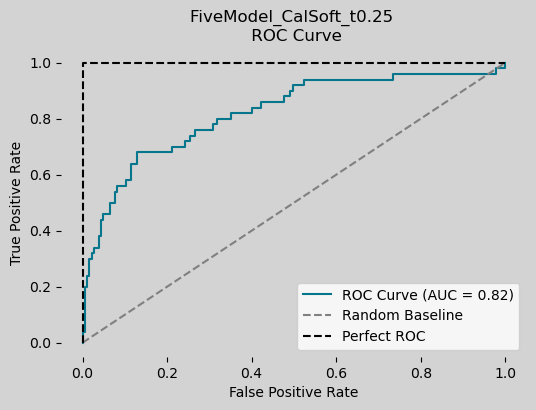

{'roc_auc': 0.8208648648648649}

In [6]:
#ROC Curve with Perfect Reference
plot_roc_with_perfect_reference(
    y_true=y_test,
    y_proba=y_proba,
    model_name='FiveModel_CalSoft_t0.25'
)

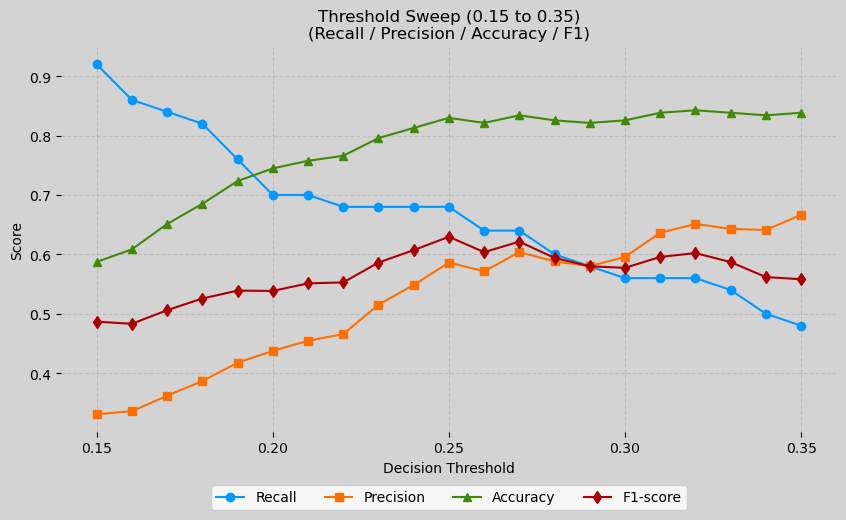

In [7]:
# --- TEST of Threshold Sweep Plot ---

#Threshold Sweep from 0.15 to 0.35
sweep_df = threshold_sweep(
    y_true=y_test,
    y_proba=y_proba,
    threshold_min=0.15,
    threshold_max=0.35,
    threshold_step=0.01,)

#Plot 
plot_threshold_sweep_metrics(
    sweep_df,
    metric_cols=['recall1', 'precision1', 'accuracy', 'f1',],
    title='Threshold Sweep (0.15 to 0.35)\n(Recall / Precision / Accuracy / F1)',
    output_title="Threshold_Sweep_Limited_Metrics")

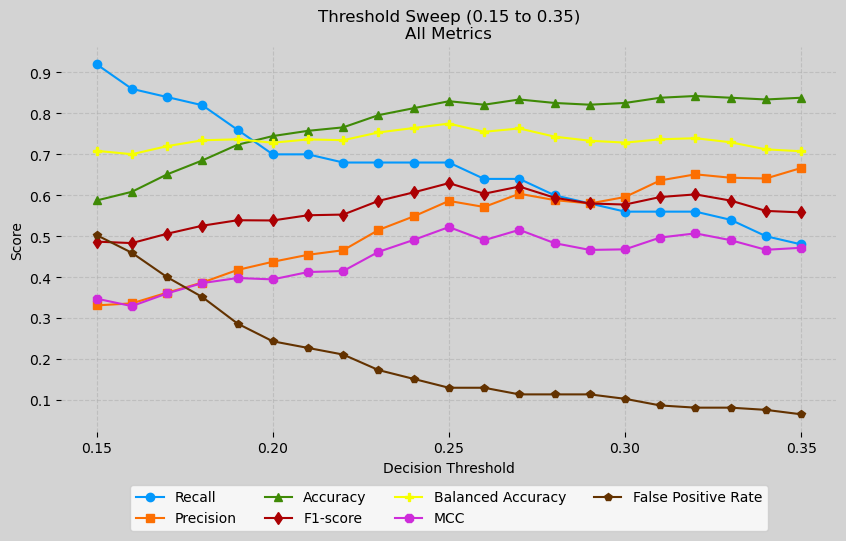

In [8]:
#Plot 
plot_threshold_sweep_metrics(
    sweep_df,
    metric_cols=['recall1', 'precision1', 'accuracy', 'f1', 'bal_acc', 'mcc', 'fpr',],
    title='Threshold Sweep (0.15 to 0.35)\nAll Metrics',
    output_title="Threshold_Sweep_All_Metrics")

In [9]:
#Load precomputed diagnostic tables from results exports
threshold_sweep_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Threshold_Sweep.xlsx')
segment_metrics_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Segment_Metrics.xlsx')
triangulation_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Feature_Triangulation_Comparison.xlsx')
fn_shap_df = pd.read_excel('/Users/matthewplambeck/Desktop/Convoy Predictor/results/Feature_Triangulation_FN_SHAP.xlsx')

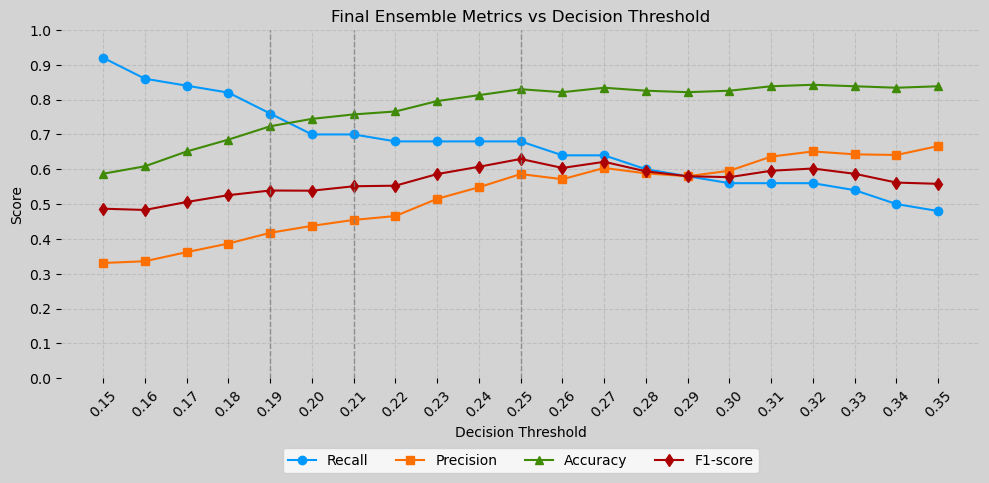

<Axes: title={'center': 'Final Ensemble Metrics vs Decision Threshold'}, xlabel='Decision Threshold', ylabel='Score'>

In [10]:
#Threshold Trade-off Curve
plot_threshold_tradeoff_curve(
    sweep_df=threshold_sweep_df,
    marker_thresholds=(0.25, 0.21, 0.19),
    title='Final Ensemble Metrics vs Decision Threshold',
    model_name='FiveModel_CalSoft_t0.25'
)